<a href="https://colab.research.google.com/github/KesteHarshada87/DeepLearning/blob/main/Experiment01-A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [11]:
#100 samples and each having 5 features
X = np.random.rand(100,5)

#Output 0 or 1
y = np.random.randint(0, 2, 100)


In [5]:
model = Sequential()

# Input layer
model.add(Dense(32, activation='relu', input_shape=(5,)))

# Hidden layers (8 layers)
for _ in range(8):
    model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [12]:
model.fit(X, y, epochs=10, batch_size=10)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4631 - loss: 0.7062 
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6282 - loss: 0.6858 
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5535 - loss: 0.6865 
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5901 - loss: 0.6786 
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6019 - loss: 0.6755 
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5371 - loss: 0.6982 
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6826 - loss: 0.6457 
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5998 - loss: 0.6610 
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5512 - loss: 0.6860 
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6526 - loss: 0.6382 


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,021 (101.65 KB)

 Trainable params: 8,673 (33.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,348 (67.77 KB)

In [15]:
#Vanishing gradient problem
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

# FIX: reshape y to (100, 1)
y_tensor = tf.reshape(y_tensor, (-1, 1))

with tf.GradientTape() as tape:
    predictions = model(X_tensor)
    loss = tf.keras.losses.binary_crossentropy(y_tensor, predictions)

gradients = tape.gradient(loss, model.trainable_weights)



In [16]:
layer_gradient_magnitudes = []

for i in range(0, len(gradients), 2):   # step=2 (kernel + bias)
    kernel_grad = gradients[i]
    bias_grad = gradients[i + 1]

    # Mean absolute gradient for the layer
    layer_mean_grad = (
        tf.reduce_mean(tf.abs(kernel_grad)) +
        tf.reduce_mean(tf.abs(bias_grad))
    ) / 2

    layer_gradient_magnitudes.append(layer_mean_grad.numpy())


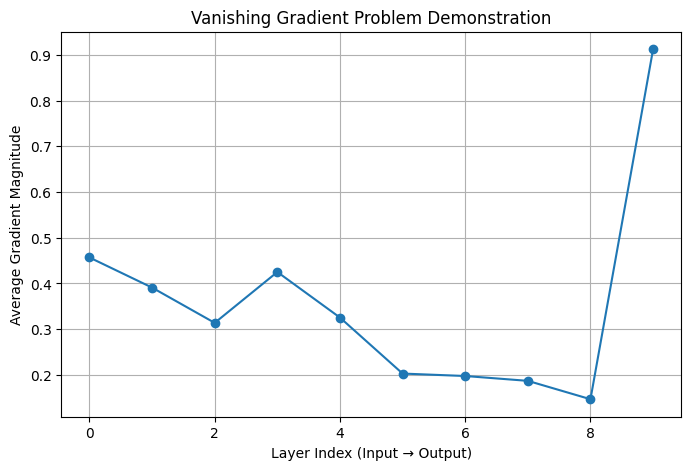

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(layer_gradient_magnitudes, marker='o')
plt.xlabel("Layer Index (Input → Output)")
plt.ylabel("Average Gradient Magnitude")
plt.title("Vanishing Gradient Problem Demonstration")
plt.grid(True)
plt.show()


In [18]:
#Exploidong Gradient Descent
from tensorflow.keras import initializers

model_exploding = Sequential()

# Input layer with large weights
model_exploding.add(Dense(32, activation='relu',
                          input_shape=(5,),
                          kernel_initializer=initializers.RandomNormal(mean=0.0, stddev=3.0)))

# 8 hidden layers
for _ in range(8):
    model_exploding.add(Dense(32, activation='relu',
                              kernel_initializer=initializers.RandomNormal(mean=0.0, stddev=3.0)))

# Output layer
model_exploding.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model_exploding.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Dummy data (same as before)
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)
y_tensor = tf.reshape(y_tensor, (-1, 1))

# Train a few epochs
model_exploding.fit(X_tensor, y_tensor, epochs=3, batch_size=16, verbose=0)


In [20]:
with tf.GradientTape() as tape:
    predictions = model_exploding(X_tensor)
    loss = tf.keras.losses.binary_crossentropy(y_tensor, predictions)

gradients = tape.gradient(loss, model_exploding.trainable_weights)


In [21]:
layer_gradients_exploding = []

for i in range(0, len(gradients), 2):
    kernel_grad = gradients[i]
    bias_grad = gradients[i+1]

    layer_mean_grad = (
        tf.reduce_mean(tf.abs(kernel_grad)) +
        tf.reduce_mean(tf.abs(bias_grad))
    ) / 2

    layer_gradients_exploding.append(layer_mean_grad.numpy())


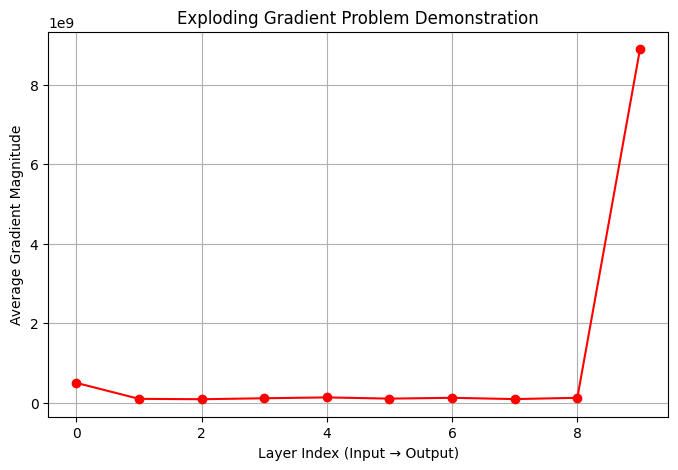

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(layer_gradients_exploding, marker='o', color='r')
plt.xlabel("Layer Index (Input → Output)")
plt.ylabel("Average Gradient Magnitude")
plt.title("Exploding Gradient Problem Demonstration")
plt.grid(True)
plt.show()


In [24]:
#Symmetry Problem
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import initializers
import numpy as np

# -----------------------------
# 1️⃣ CREATE DUMMY DATA
# -----------------------------
np.random.seed(0)
X = np.random.rand(10, 3)        # smaller batch for clarity
y = np.random.randint(0, 2, 10)

X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)
y_tensor = tf.reshape(y_tensor, (-1, 1))

# -----------------------------
# 2️⃣ SYMMETRY PROBLEM NETWORK
# -----------------------------
symmetry_model = Sequential()

# Hidden layer with identical weights (all 0.5)
symmetry_model.add(Dense(3, activation='relu', input_shape=(3,),
                         kernel_initializer=initializers.Constant(0.5),
                         bias_initializer=initializers.Constant(0.0)))

# Output layer
symmetry_model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# 3️⃣ COMPUTE GRADIENTS
# -----------------------------
with tf.GradientTape() as tape:
    predictions = symmetry_model(X_tensor)
    loss = tf.keras.losses.binary_crossentropy(y_tensor, predictions)
    loss = tf.reduce_mean(loss)  # Important: make scalar

gradients = tape.gradient(loss, symmetry_model.trainable_weights)

# -----------------------------
# 4️⃣ DISPLAY GRADIENTS
# -----------------------------
print("Kernel gradients (all should be identical):")
print(gradients[0].numpy())

print("Bias gradients (all should be identical):")
print(gradients[1].numpy())


Kernel gradients (all should be identical):
[[ 0.05721912 -0.10160363  0.0687122 ]
 [ 0.03876714 -0.06883859  0.04655396]
 [ 0.07143729 -0.12685077  0.08578627]]
Bias gradients (all should be identical):
[ 0.10707281 -0.19012854  0.12857957]


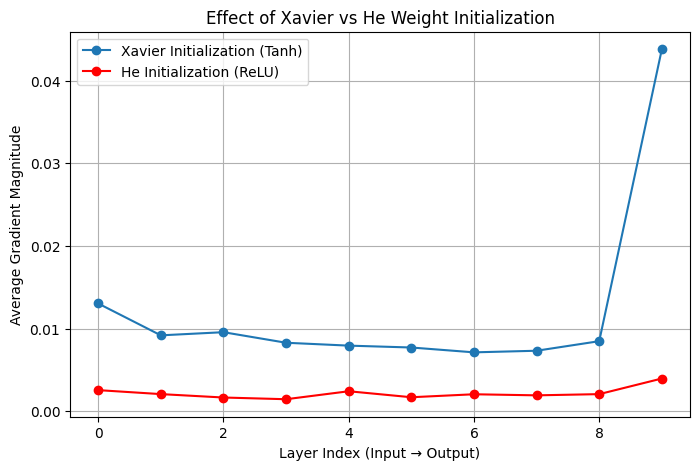

In [26]:
# -----------------------------
# Xavier and He Initialization Demo for Existing Data
# -----------------------------

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import initializers
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ CREATE / USE EXISTING DATA
# -----------------------------
np.random.seed(0)
X = np.random.rand(100, 5)        # 100 samples, 5 features
y = np.random.randint(0, 2, 100)  # Binary labels

X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)
y_tensor = tf.reshape(y_tensor, (-1,1))  # reshape for binary crossentropy

# -----------------------------
# 2️⃣ XAVIER (GLOROT) INITIALIZATION MODEL
# -----------------------------
xavier_model = Sequential([
    Input(shape=(5,)),  # Proper Input layer
    Dense(32, activation='tanh', kernel_initializer='glorot_uniform')
])

for _ in range(8):
    xavier_model.add(Dense(32, activation='tanh', kernel_initializer='glorot_uniform'))

xavier_model.add(Dense(1, activation='sigmoid'))

xavier_model.compile(optimizer='adam', loss='binary_crossentropy')
xavier_model.fit(X_tensor, y_tensor, epochs=3, batch_size=16, verbose=0)

# -----------------------------
# 3️⃣ HE INITIALIZATION MODEL
# -----------------------------
he_model = Sequential([
    Input(shape=(5,)),
    Dense(32, activation='relu', kernel_initializer='he_normal')
])

for _ in range(8):
    he_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))

he_model.add(Dense(1, activation='sigmoid'))

he_model.compile(optimizer='adam', loss='binary_crossentropy')
he_model.fit(X_tensor, y_tensor, epochs=3, batch_size=16, verbose=0)

# -----------------------------
# 4️⃣ COMPUTE LAYER-WISE GRADIENTS (OPTIONAL)
# -----------------------------
def compute_layer_gradients(model, X_tensor, y_tensor):
    with tf.GradientTape() as tape:
        predictions = model(X_tensor)
        loss = tf.keras.losses.binary_crossentropy(y_tensor, predictions)
        loss = tf.reduce_mean(loss)
    gradients = tape.gradient(loss, model.trainable_weights)

    layer_gradients = []
    for i in range(0, len(gradients), 2):
        kernel_grad = gradients[i]
        bias_grad = gradients[i+1]
        layer_mean = (tf.reduce_mean(tf.abs(kernel_grad)) + tf.reduce_mean(tf.abs(bias_grad))) / 2
        layer_gradients.append(layer_mean.numpy())
    return layer_gradients

xavier_gradients = compute_layer_gradients(xavier_model, X_tensor, y_tensor)
he_gradients = compute_layer_gradients(he_model, X_tensor, y_tensor)

# -----------------------------
# 5️⃣ PLOT GRADIENTS FOR COMPARISON
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(xavier_gradients, marker='o', label='Xavier Initialization (Tanh)')
plt.plot(he_gradients, marker='o', label='He Initialization (ReLU)', color='r')
plt.xlabel("Layer Index (Input → Output)")
plt.ylabel("Average Gradient Magnitude")
plt.title("Effect of Xavier vs He Weight Initialization")
plt.legend()
plt.grid(True)
plt.show()
